In [12]:
import pandas as pd

df = pd.read_csv("../data/clean_airline_reviews.csv")

In [14]:
def severity_label(rating):
    if rating <= 2:
        return "Critical"
    elif rating <= 4:
        return "High"
    elif rating <= 6:
        return "Medium"
    else:
        return "Low"

df["Overall_Rating"] = pd.to_numeric(df["Overall_Rating"], errors="coerce")
df["severity_label"] = df["Overall_Rating"].apply(severity_label)

In [15]:
df["risk_label"] = df["severity_label"].apply(
    lambda x: 1 if x in ["Critical", "High"] else 0
)

In [16]:
df["risk_label"].value_counts()

risk_label
1    16106
0     7065
Name: count, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X = df["final_text"]
y = df["risk_label"]

vectorizer = TfidfVectorizer(max_features=5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [18]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.68      0.71      1413
           1       0.86      0.90      0.88      3222

    accuracy                           0.83      4635
   macro avg       0.80      0.79      0.79      4635
weighted avg       0.83      0.83      0.83      4635

Accuracy: 0.8299892125134843


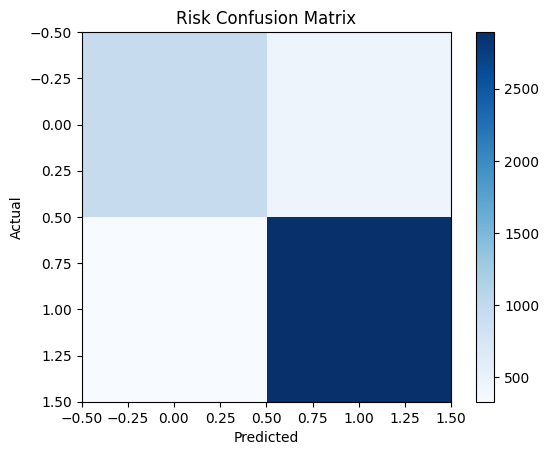

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title("Risk Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
import joblib

joblib.dump(model, "../models/risk_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_risk.pkl")

['../models/tfidf_risk.pkl']

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [20]:
import pickle

pickle.dump(model, open("../models/risk_model.pkl", "wb"))
pickle.dump(vectorizer, open("../models/tfidf_risk.pkl", "wb"))

print("Model saved successfully")

Model saved successfully
